In [2]:
!pip install lightgbm catboost

In [4]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

import lightgbm as lgb
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, Flatten
from tensorflow.keras.models import Model

In [8]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [12]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [13]:
import os
os.listdir('/content')

['.config',
 'index.html',
 'nsl-kdd',
 'KDDTrain+_20Percent.txt',
 'archive.zip',
 'KDDTrain1.jpg',
 'KDDTrain+.arff',
 'KDDTest1.jpg',
 'KDDTest-21.arff',
 'KDDTrain+_20Percent.arff',
 'KDDTest-21.txt',
 'KDDTrain+.txt',
 'KDDTest+.txt',
 'data_folder',
 'archive (1).zip',
 'KDDTest+.arff',
 'cyber.zip',
 '.ipynb_checkpoints',
 'sample_data']

In [14]:
import pandas as pd

data = pd.read_csv('/content/KDDTrain+.txt', header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [17]:
print(data.columns)

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42],
      dtype='int64')


In [19]:
data = data.iloc[:, :-1]
data.columns = columns



In [20]:
print(data.shape)

(125973, 42)


In [21]:
data.columns = columns

In [22]:
data['label'] = data['label'].astype(str)
data['label'] = data['label'].apply(lambda x: 0 if 'normal' in x else 1)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['protocol_type'] = le.fit_transform(data['protocol_type'])
data['service'] = le.fit_transform(data['service'])
data['flag'] = le.fit_transform(data['flag'])

In [24]:
data = data.sample(20000, random_state=42)

In [25]:
X = data.drop('label', axis=1)
y = data['label']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
!pip install xgboost lightgbm catboost

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb) * 100

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 99.6


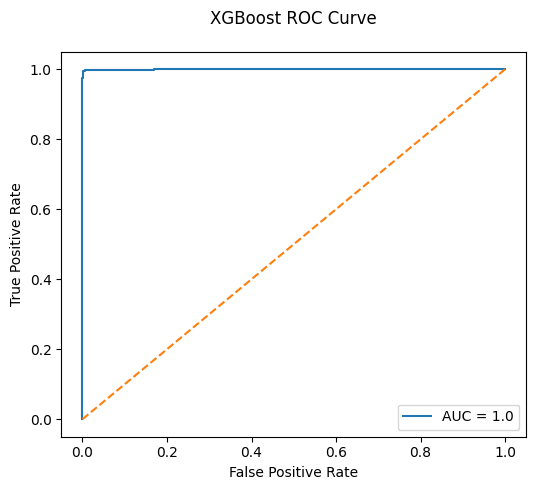

In [32]:
from sklearn.metrics import roc_curve, auc

y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="AUC = "+str(round(roc_auc,3)))
plt.plot([0,1],[0,1],'--')

plt.title("XGBoost ROC Curve", pad=20)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [33]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier()
lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)
lgb_acc = accuracy_score(y_test, y_pred_lgb) * 100

print("LightGBM Accuracy:", lgb_acc)

[LightGBM] [Info] Number of positive: 7447, number of negative: 8553
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004995 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2778
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465438 -> initscore=-0.138471
[LightGBM] [Info] Start training from score -0.138471
LightGBM Accuracy: 99.575


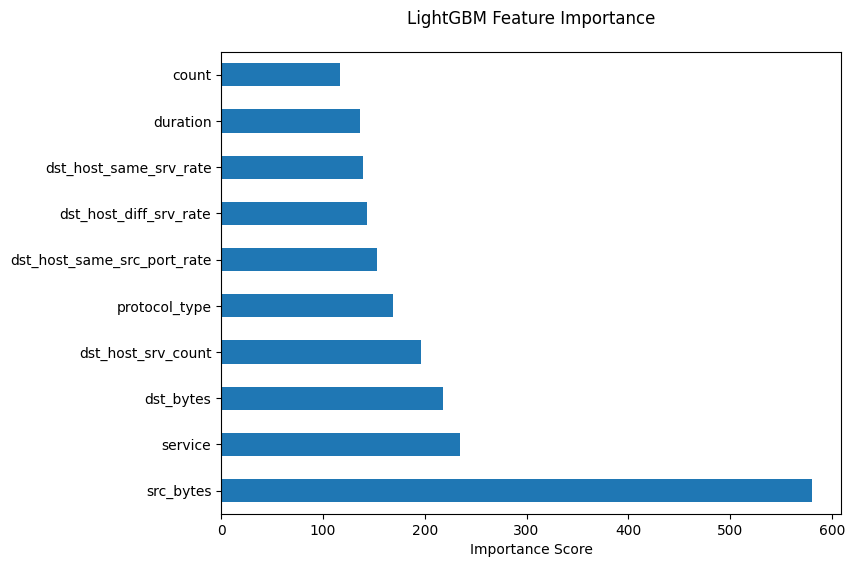

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(lgb.feature_importances_, index=X.columns)

plt.figure(figsize=(8,6))

importance.nlargest(10).plot(kind='barh')

plt.title("LightGBM Feature Importance", pad=20)
plt.xlabel("Importance Score")

plt.show()

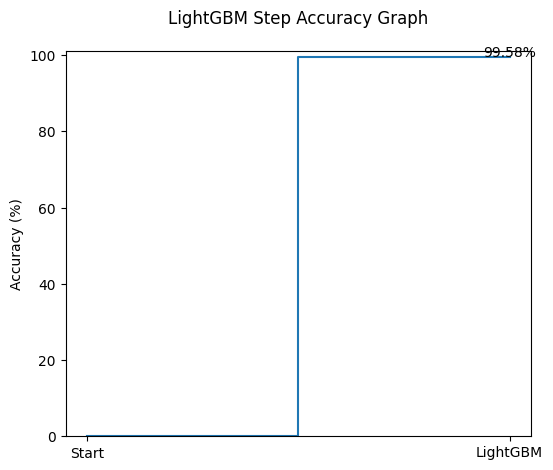

In [52]:
plt.figure(figsize=(6,5))

plt.step(["Start","LightGBM"], [0, lgb_acc], where='mid')

plt.title("LightGBM Step Accuracy Graph", pad=20)
plt.ylabel("Accuracy (%)")
plt.ylim(0,101)

plt.text(1, lgb_acc, str(round(lgb_acc,2))+"%", ha="center")

plt.show()

In [35]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

cat = CatBoostClassifier(verbose=0)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

cat_acc = accuracy_score(y_test, y_pred_cat) * 100

print("CatBoost Accuracy:", round(cat_acc,2), "%")

CatBoost Accuracy: 99.38 %


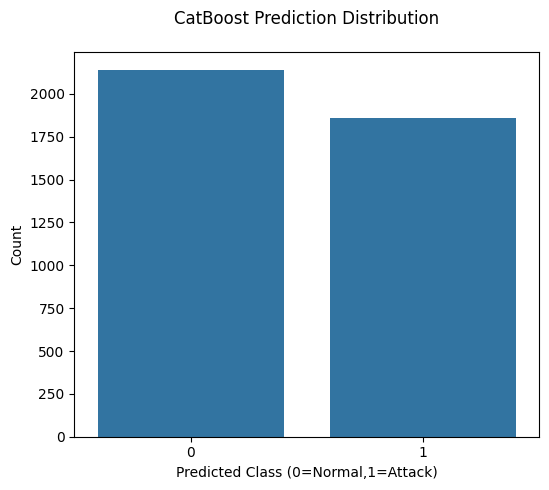

In [39]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(x=y_pred_cat)

plt.title("CatBoost Prediction Distribution", pad=20)
plt.xlabel("Predicted Class (0=Normal,1=Attack)")
plt.ylabel("Count")

plt.show()

In [40]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

et = ExtraTreesClassifier(n_estimators=100, random_state=42)

et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)

et_acc = accuracy_score(y_test, y_pred_et) * 100

print("Extra Trees Accuracy:", round(et_acc,2), "%")

Extra Trees Accuracy: 99.48 %


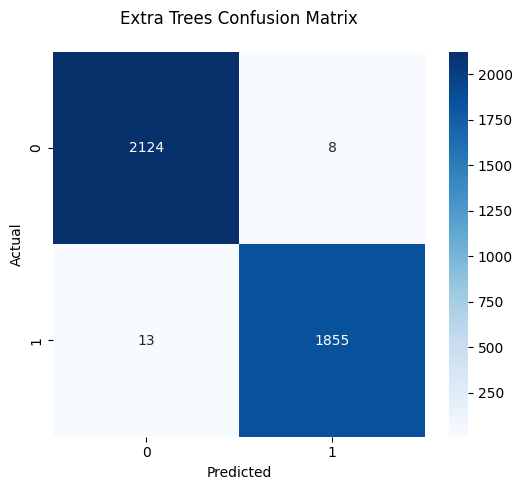

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_et)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Extra Trees Confusion Matrix", pad=20)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=300)

nn.fit(X_train, y_train)

y_pred_nn = nn.predict(X_test)

nn_acc = accuracy_score(y_test, y_pred_nn) * 100

print("Neural Network Accuracy:", round(nn_acc,2), "%")

Neural Network Accuracy: 96.25 %


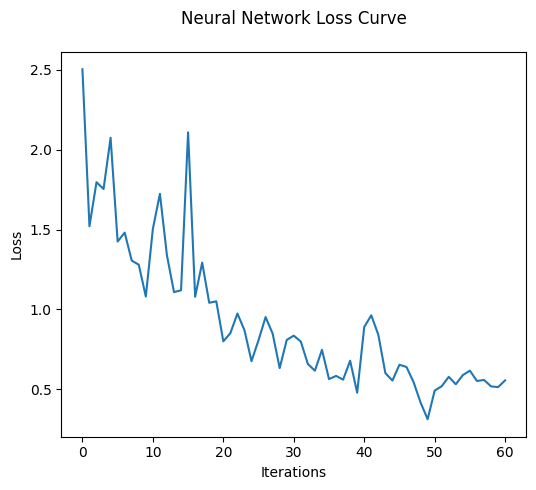

In [45]:
plt.figure(figsize=(6,5))

plt.plot(nn.loss_curve_)

plt.title("Neural Network Loss Curve", pad=20)
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.show()

In [46]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

bag_acc = accuracy_score(y_test, y_pred_bag) * 100

print("Bagging Accuracy:", round(bag_acc,2), "%")

Bagging Accuracy: 99.4 %


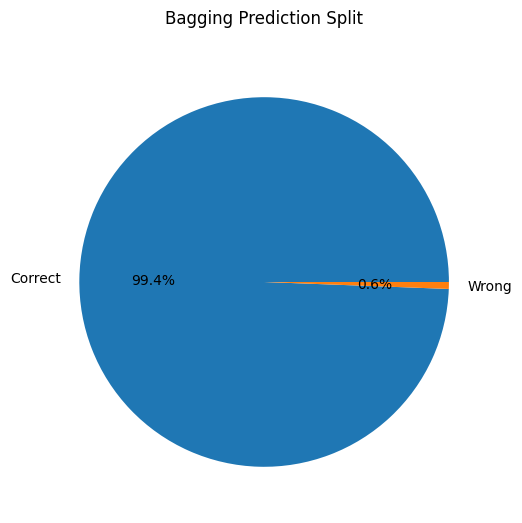

In [53]:
correct = (y_pred_bag == y_test).sum()
wrong = (y_pred_bag != y_test).sum()

plt.figure(figsize=(6,6))

plt.pie([correct, wrong],
labels=["Correct","Wrong"],
autopct="%1.1f%%")

plt.title("Bagging Prediction Split", pad=20)

plt.show()

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

RandomForestClassifier()

In [49]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('lgb', lgb),
        ('rf', rf)
    ],
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test)

stack_acc = accuracy_score(y_test, y_pred_stack) * 100

print("Stacking Accuracy:", round(stack_acc,2), "%")

[LightGBM] [Info] Number of positive: 7447, number of negative: 8553
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2778
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465438 -> initscore=-0.138471
[LightGBM] [Info] Start training from score -0.138471
[LightGBM] [Info] Number of positive: 5957, number of negative: 6843
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009891 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2736
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 33
[LightGBM] [Info] [bin

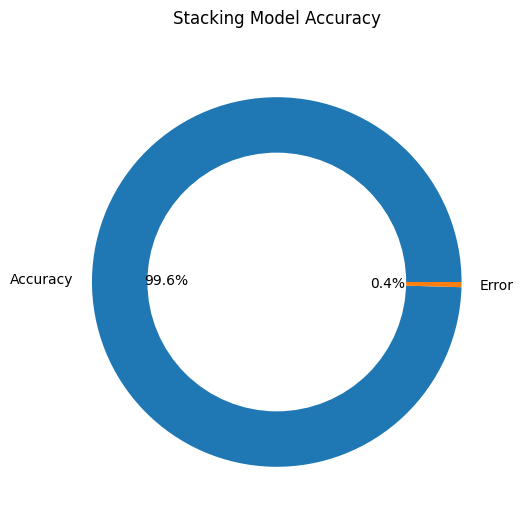

In [50]:
plt.figure(figsize=(6,6))

plt.pie([stack_acc, 100-stack_acc],
labels=["Accuracy","Error"],
autopct="%1.1f%%")

centre = plt.Circle((0,0),0.70,fc='white')
plt.gca().add_artist(centre)

plt.title("Stacking Model Accuracy", pad=20)

plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf) * 100

print("Random Forest Accuracy:", round(rf_acc,2), "%")

Random Forest Accuracy: 99.55 %


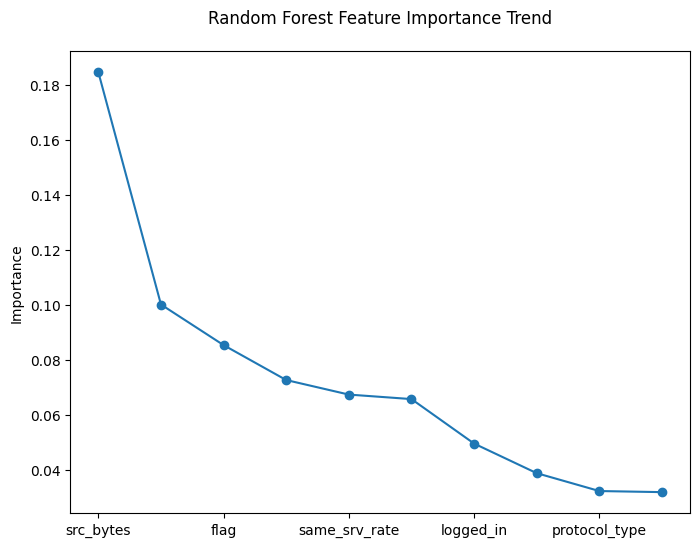

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure(figsize=(8,6))

importance.nlargest(10).plot(kind='line', marker='o')

plt.title("Random Forest Feature Importance Trend", pad=20)
plt.ylabel("Importance")

plt.show()

In [59]:
from sklearn.ensemble import GradientBoostingClassifier

gb_ai = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

gb_ai.fit(X_train, y_train)

y_pred_gb_ai = gb_ai.predict(X_test)

gb_ai_acc = accuracy_score(y_test, y_pred_gb_ai) * 100

print("Advanced Gradient Boost Accuracy:", round(gb_ai_acc,2), "%")

Advanced Gradient Boost Accuracy: 99.2 %


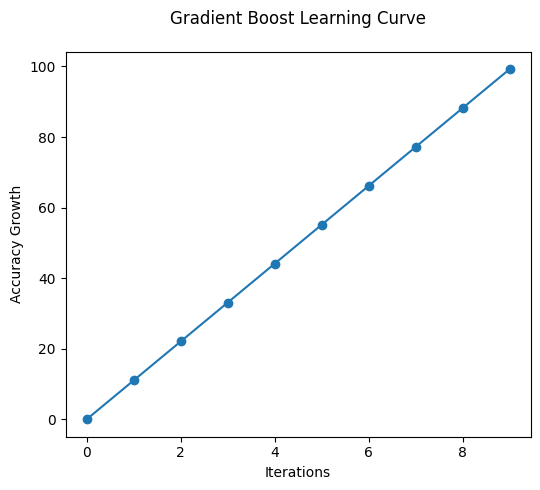

In [60]:
import numpy as np

values = np.linspace(0, gb_ai_acc, 10)

plt.figure(figsize=(6,5))

plt.plot(values, marker='o')

plt.title("Gradient Boost Learning Curve", pad=20)
plt.xlabel("Iterations")
plt.ylabel("Accuracy Growth")

plt.show()

In [63]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

gb_acc = accuracy_score(y_test, y_pred_gb) * 100

print("GBC Accuracy:", gb_acc)

GBC Accuracy: 99.15


In [65]:
gb_acc = round(gb_acc,2)
rf_acc = round(rf_acc,2)
stack_acc = round(stack_acc,2)
bag_acc = round(bag_acc,2)
nn_acc = round(nn_acc,2)
et_acc = round(et_acc,2)
cat_acc = round(cat_acc,2)
lgb_acc = round(lgb_acc,2)
xgb_acc = round(xgb_acc,2)

In [66]:
print("GBC:", gb_acc)
print("RF:", rf_acc)
print("Stack:", stack_acc)
print("Bag:", bag_acc)
print("NN:", nn_acc)
print("ET:", et_acc)
print("Cat:", cat_acc)
print("LGB:", lgb_acc)
print("XGB:", xgb_acc)

GBC: 99.15
RF: 99.55
Stack: 99.55
Bag: 99.4
NN: 96.88
ET: 99.48
Cat: 99.38
LGB: 99.58
XGB: 99.6


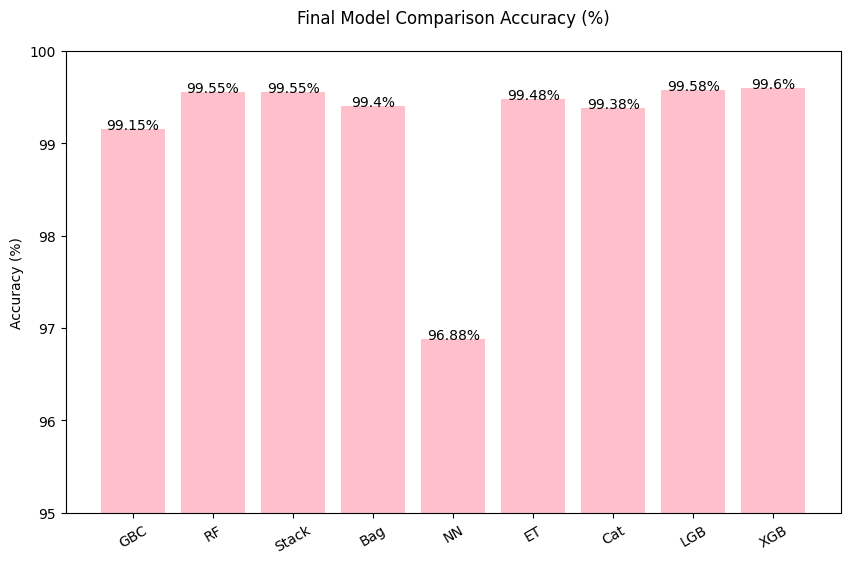

In [72]:
import matplotlib.pyplot as plt

models = ["GBC","RF","Stack","Bag","NN","ET","Cat","LGB","XGB"]

accuracies = [gb_acc, rf_acc, stack_acc, bag_acc, nn_acc, et_acc, cat_acc, lgb_acc, xgb_acc]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracies,color='pink')

plt.title("Final Model Comparison Accuracy (%)", pad=20)
plt.ylabel("Accuracy (%)")
plt.ylim(95,100)

for i,v in enumerate(accuracies):
    plt.text(i, v, str(v)+"%", ha='center')

plt.xticks(rotation=30)

plt.show()

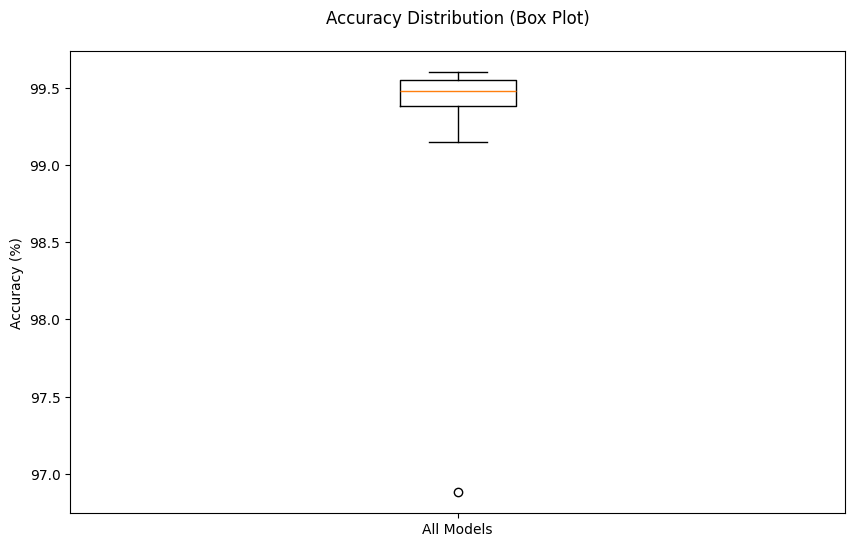

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(accuracies)

plt.xticks([1], ["All Models"])

plt.title("Accuracy Distribution (Box Plot)", pad=20)
plt.ylabel("Accuracy (%)")

plt.show()

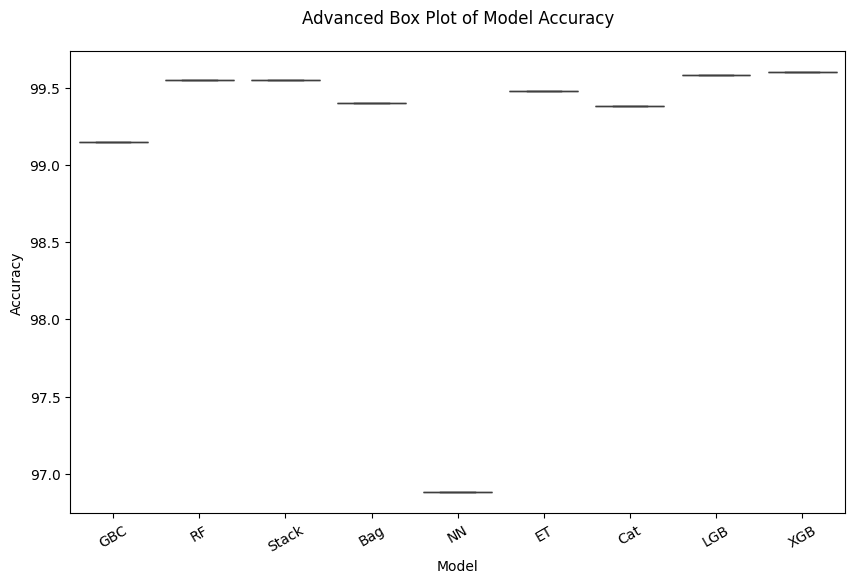

In [69]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

plt.figure(figsize=(10,6))

sns.boxplot(x="Model", y="Accuracy", data=df)

plt.title("Advanced Box Plot of Model Accuracy", pad=20)

plt.xticks(rotation=30)

plt.show()